# Embedding Space Visualization

How embedding models represent text as vectors — and what that looks like geometrically. This notebook explores embedding spaces using **all-MiniLM-L6-v2** (384 dimensions).

**What we'll cover:**
1. Embedding text chunks from different topics
2. Cosine similarity between chunks
3. Dimensionality reduction with t-SNE to visualize clusters
4. How query embeddings land relative to document chunks
5. Comparing chunking strategies in embedding space

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

from src.ingest.embedders import Embedder
from src.ingest.chunkers import fixed_chunker, recursive_chunker, sentence_chunker

/Users/ankur/cowork/learning/rag/rag-learning-lab/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Embedding Model

We use all-MiniLM-L6-v2 — a small (80 MB) but effective model that produces 384-dimensional vectors.

In [2]:
embedder = Embedder("all-MiniLM-L6-v2")
print(f"Model: {embedder.model_name}")
print(f"Embedding dimension: {embedder.dimension}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9710.56it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model: all-MiniLM-L6-v2
Embedding dimension: 384


## 2. Sample Texts from Different Topics

We embed sentences from three distinct topics to see how the model separates them in vector space.

In [3]:
topic_sentences = {
    "Machine Learning": [
        "Neural networks learn patterns from training data.",
        "Gradient descent optimizes model parameters iteratively.",
        "Overfitting occurs when a model memorizes training examples.",
        "Cross-validation helps estimate generalization performance.",
        "Feature engineering transforms raw data into useful representations.",
    ],
    "Cooking": [
        "Caramelizing onions requires low heat and patience.",
        "A sharp knife is the most important kitchen tool.",
        "Bread dough needs time to rise before baking.",
        "Seasoning with salt enhances natural flavors.",
        "Searing meat at high heat creates a flavorful crust.",
    ],
    "Astronomy": [
        "Black holes have gravity so strong that light cannot escape.",
        "The Milky Way contains hundreds of billions of stars.",
        "Neutron stars are incredibly dense collapsed stellar cores.",
        "The universe is expanding at an accelerating rate.",
        "Exoplanets are detected by measuring stellar brightness dips.",
    ],
}

all_texts = []
all_labels = []
for topic, sentences in topic_sentences.items():
    all_texts.extend(sentences)
    all_labels.extend([topic] * len(sentences))

embeddings = embedder.embed(all_texts)
print(f"Embedded {len(all_texts)} sentences → shape {embeddings.shape}")

Embedded 15 sentences → shape (15, 384)


## 3. Cosine Similarity Matrix

Cosine similarity measures how close two vectors are in direction (ignoring magnitude). Values range from -1 (opposite) to 1 (identical). Sentences about the same topic should cluster together.

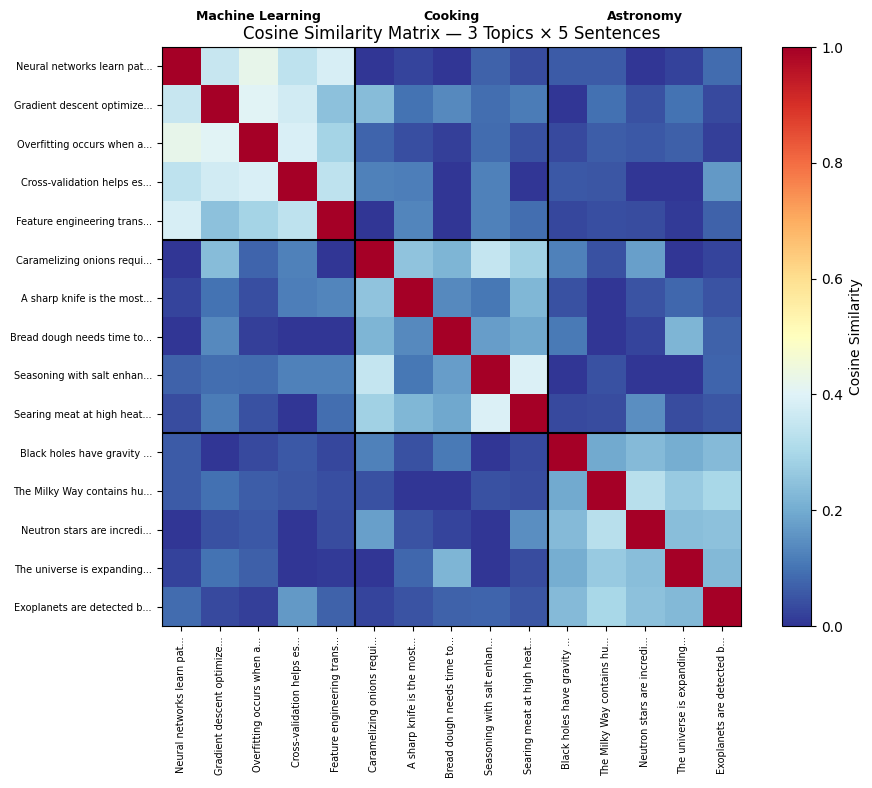

In [4]:
# Compute cosine similarity matrix
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
normalized = embeddings / norms
sim_matrix = normalized @ normalized.T

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sim_matrix, cmap="RdYlBu_r", vmin=0, vmax=1)

# Add topic boundary lines
boundary = 0
for topic in topic_sentences:
    n = len(topic_sentences[topic])
    ax.axhline(y=boundary - 0.5, color="black", linewidth=1.5)
    ax.axvline(x=boundary - 0.5, color="black", linewidth=1.5)
    ax.text(boundary + n / 2 - 0.5, -1.2, topic, ha="center", fontsize=9, fontweight="bold")
    boundary += n

ax.set_xticks(range(len(all_texts)))
ax.set_yticks(range(len(all_texts)))
ax.set_xticklabels([t[:25] + "..." for t in all_texts], rotation=90, fontsize=7)
ax.set_yticklabels([t[:25] + "..." for t in all_texts], fontsize=7)
ax.set_title("Cosine Similarity Matrix — 3 Topics × 5 Sentences")
plt.colorbar(im, ax=ax, label="Cosine Similarity")
plt.tight_layout()
plt.show()

The diagonal blocks should be brighter (higher similarity within topics) and off-diagonal blocks should be darker (lower similarity across topics).

## 4. t-SNE Visualization — Embedding Clusters

384 dimensions are impossible to visualize directly. t-SNE reduces them to 2D while preserving local structure — points that are close in high-dimensional space stay close in the plot.

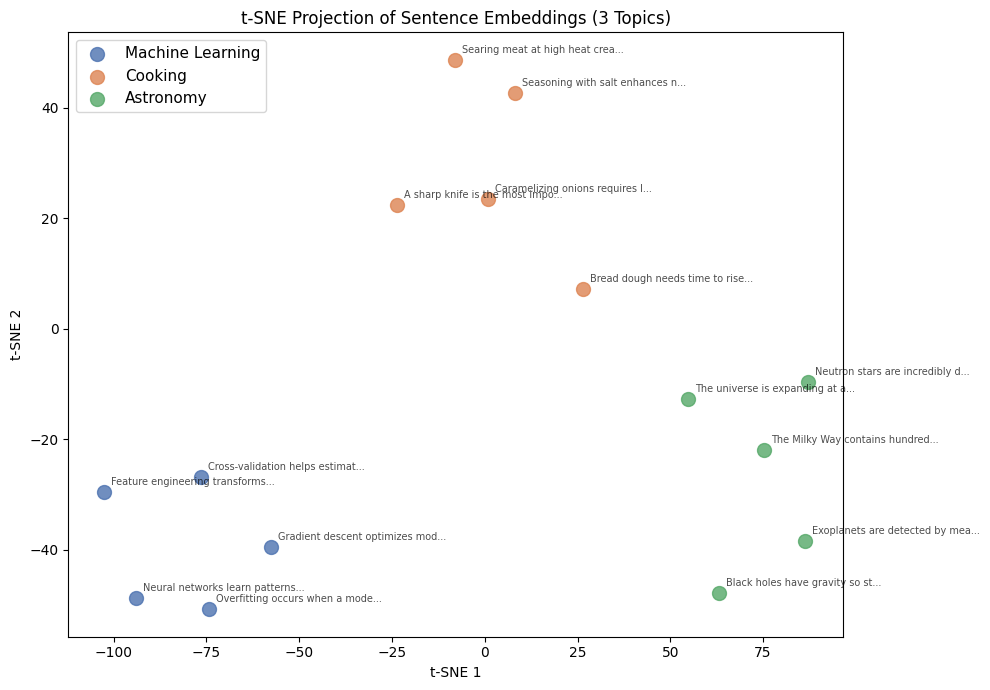

In [5]:
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
coords_2d = tsne.fit_transform(embeddings)

color_map = {"Machine Learning": "#4C72B0", "Cooking": "#DD8452", "Astronomy": "#55A868"}

fig, ax = plt.subplots(figsize=(10, 7))
for topic in topic_sentences:
    mask = [l == topic for l in all_labels]
    points = coords_2d[mask]
    ax.scatter(points[:, 0], points[:, 1], label=topic, c=color_map[topic], s=100, alpha=0.8)
    # Annotate each point with a short label
    topic_texts = topic_sentences[topic]
    for j, (x, y) in enumerate(points):
        short = topic_texts[j][:30] + "..."
        ax.annotate(short, (x, y), fontsize=7, alpha=0.7,
                    xytext=(5, 5), textcoords="offset points")

ax.legend(fontsize=11)
ax.set_title("t-SNE Projection of Sentence Embeddings (3 Topics)")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

## 5. Query Embedding Placement

When a user asks a question, their query gets embedded into the same vector space. The retriever finds the closest document chunks. Let's see where queries land relative to our topic clusters.

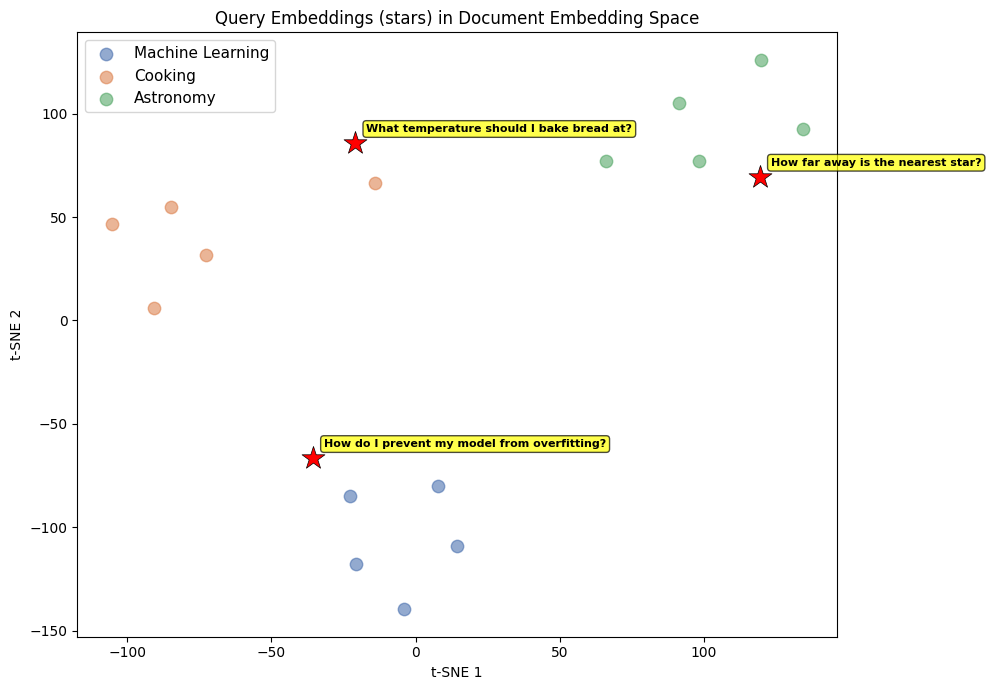

In [6]:
queries = [
    "How do I prevent my model from overfitting?",
    "What temperature should I bake bread at?",
    "How far away is the nearest star?",
]

query_embeddings = embedder.embed(queries)

# Re-run t-SNE with queries included
all_vecs = np.vstack([embeddings, query_embeddings])
tsne_all = TSNE(n_components=2, random_state=42, perplexity=5)
coords_all = tsne_all.fit_transform(all_vecs)

doc_coords = coords_all[:len(all_texts)]
query_coords = coords_all[len(all_texts):]

fig, ax = plt.subplots(figsize=(10, 7))

# Plot document embeddings
for topic in topic_sentences:
    mask = [l == topic for l in all_labels]
    points = doc_coords[mask]
    ax.scatter(points[:, 0], points[:, 1], label=topic, c=color_map[topic], s=80, alpha=0.6)

# Plot query embeddings as stars
for i, (x, y) in enumerate(query_coords):
    ax.scatter(x, y, marker="*", s=300, c="red", edgecolors="black", linewidths=0.5, zorder=5)
    ax.annotate(queries[i], (x, y), fontsize=8, fontweight="bold",
                xytext=(8, 8), textcoords="offset points",
                bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.7))

ax.legend(fontsize=11)
ax.set_title("Query Embeddings (stars) in Document Embedding Space")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

Each query (red star) should land near the cluster of its matching topic. This is exactly what a retriever does — it finds the nearest document chunks to the query embedding.

## 6. Nearest Neighbors — What the Retriever Would Find

For each query, let's compute the actual cosine similarities and see the top-3 matches:

In [7]:
for i, query in enumerate(queries):
    q_norm = query_embeddings[i] / np.linalg.norm(query_embeddings[i])
    sims = normalized @ q_norm
    top_indices = np.argsort(sims)[::-1][:3]

    print(f"Query: {query!r}")
    for rank, idx in enumerate(top_indices):
        print(f"  #{rank+1} (sim={sims[idx]:.3f}) [{all_labels[idx]}] {all_texts[idx]}")
    print()

Query: 'How do I prevent my model from overfitting?'
  #1 (sim=0.609) [Machine Learning] Overfitting occurs when a model memorizes training examples.
  #2 (sim=0.294) [Machine Learning] Gradient descent optimizes model parameters iteratively.
  #3 (sim=0.151) [Machine Learning] Cross-validation helps estimate generalization performance.

Query: 'What temperature should I bake bread at?'
  #1 (sim=0.479) [Cooking] Bread dough needs time to rise before baking.
  #2 (sim=0.183) [Cooking] Searing meat at high heat creates a flavorful crust.
  #3 (sim=0.112) [Cooking] Caramelizing onions requires low heat and patience.

Query: 'How far away is the nearest star?'
  #1 (sim=0.436) [Astronomy] The Milky Way contains hundreds of billions of stars.
  #2 (sim=0.340) [Astronomy] Exoplanets are detected by measuring stellar brightness dips.
  #3 (sim=0.271) [Astronomy] Neutron stars are incredibly dense collapsed stellar cores.



## 7. Chunking Strategy Comparison in Embedding Space

Different chunking strategies produce different chunks from the same document. Let's see how those chunks distribute in embedding space.

In [8]:
SAMPLE_DOC = """Retrieval-Augmented Generation (RAG) is a technique that combines the strengths of large language models with external knowledge retrieval. Instead of relying solely on the model's parametric memory, RAG systems fetch relevant documents from a knowledge base and include them in the prompt context. This approach reduces hallucination and allows the model to reference up-to-date or domain-specific information.

The first step in building a RAG system is document ingestion. Raw documents must be parsed into plain text. This text is then split into smaller pieces called chunks. The quality of chunking directly affects retrieval: chunks that are too large dilute the signal with irrelevant context, while chunks that are too small lose coherence.

Fixed-size chunking is the simplest strategy. It splits text into windows of N characters with an optional overlap. However, fixed chunking ignores document structure entirely. A chunk boundary might fall in the middle of a sentence or even a word.

Recursive chunking addresses this by trying to split at natural boundaries. It first attempts paragraph breaks, then sentences, then words, and finally characters. This hierarchy preserves semantic coherence at the cost of slightly variable chunk sizes.

Sentence-based chunking identifies sentence boundaries and packs complete sentences into chunks up to a maximum size. Every chunk contains grammatically complete units of meaning, which can improve both retrieval precision and generated answer quality."""

strategies = {
    "Fixed 256": fixed_chunker(SAMPLE_DOC.strip(), chunk_size=256, chunk_overlap=25),
    "Recursive 256": recursive_chunker(SAMPLE_DOC.strip(), chunk_size=256, chunk_overlap=25),
    "Sentence 256": sentence_chunker(SAMPLE_DOC.strip(), chunk_size=256, chunk_overlap=25),
}

# Embed all chunks from all strategies
all_chunk_texts = []
all_chunk_labels = []
for strategy_name, chunks in strategies.items():
    for c in chunks:
        all_chunk_texts.append(c.text)
        all_chunk_labels.append(strategy_name)

chunk_embeddings = embedder.embed(all_chunk_texts)
print(f"Total chunks across strategies: {len(all_chunk_texts)}")
for name, chunks in strategies.items():
    print(f"  {name}: {len(chunks)} chunks")

Total chunks across strategies: 23
  Fixed 256: 7 chunks
  Recursive 256: 7 chunks
  Sentence 256: 9 chunks


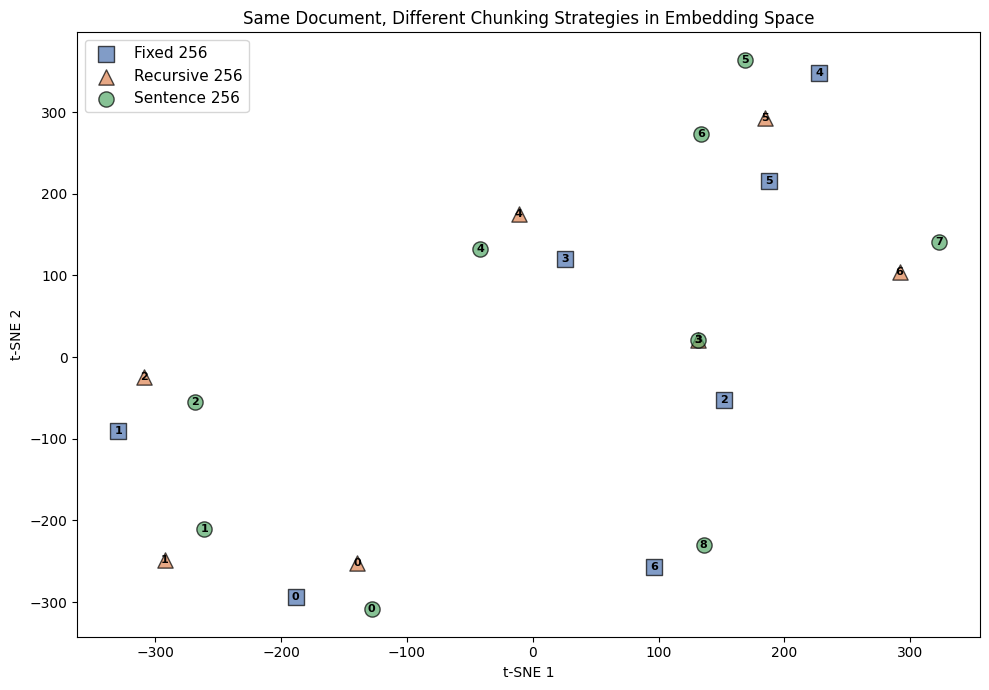

In [9]:
tsne_chunks = TSNE(n_components=2, random_state=42, perplexity=5)
chunk_coords = tsne_chunks.fit_transform(chunk_embeddings)

strategy_colors = {"Fixed 256": "#4C72B0", "Recursive 256": "#DD8452", "Sentence 256": "#55A868"}
strategy_markers = {"Fixed 256": "s", "Recursive 256": "^", "Sentence 256": "o"}

fig, ax = plt.subplots(figsize=(10, 7))
for strategy_name in strategies:
    mask = [l == strategy_name for l in all_chunk_labels]
    points = chunk_coords[mask]
    ax.scatter(points[:, 0], points[:, 1],
               label=strategy_name, c=strategy_colors[strategy_name],
               marker=strategy_markers[strategy_name], s=120, alpha=0.7, edgecolors="black")

    # Label each point with chunk index
    for j, (x, y) in enumerate(points):
        ax.annotate(str(j), (x, y), fontsize=8, ha="center", va="center", fontweight="bold")

ax.legend(fontsize=11)
ax.set_title("Same Document, Different Chunking Strategies in Embedding Space")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

## 8. Intra-Strategy Similarity

How similar are chunks to each other within each strategy? Higher intra-similarity means more redundancy (overlapping content). Lower means more diverse chunks.

In [10]:
import pandas as pd

rows = []
for strategy_name in strategies:
    mask = [l == strategy_name for l in all_chunk_labels]
    vecs = chunk_embeddings[mask]
    n = np.linalg.norm(vecs, axis=1, keepdims=True)
    normed = vecs / n
    sim = normed @ normed.T
    # Get upper triangle (excluding diagonal)
    upper = sim[np.triu_indices(len(sim), k=1)]
    rows.append({
        "Strategy": strategy_name,
        "Chunks": len(vecs),
        "Mean Intra-Sim": round(float(np.mean(upper)), 3),
        "Min Intra-Sim": round(float(np.min(upper)), 3),
        "Max Intra-Sim": round(float(np.max(upper)), 3),
    })

pd.DataFrame(rows)

,Strategy,Chunks,Mean Intra-Sim,Min Intra-Sim,Max Intra-Sim
0,Fixed 256,7,0.408,0.176,0.641
1,Recursive 256,7,0.434,0.182,0.697
2,Sentence 256,9,0.411,0.143,0.715


## Key Takeaways

- **Embedding models map semantic meaning to geometry.** Sentences about the same topic cluster together in vector space, even when they use different words.
- **Cosine similarity is the standard distance metric** for comparing embeddings. It measures directional alignment, ignoring vector magnitude.
- **t-SNE reveals cluster structure** that's invisible in 384 dimensions. Topics form clear, separated clusters.
- **Queries land near their relevant documents.** This is the foundation of vector-based retrieval — the retriever simply finds the nearest neighbors.
- **Chunking strategy affects embedding distribution.** Fixed chunking may split semantic units across chunks, creating vectors that straddle topics. Sentence and recursive chunking produce more semantically coherent chunks.
- **MiniLM-L6-v2 is effective for topic separation** despite being only 80 MB. Experiment 2 will compare it against larger models (all-mpnet-base-v2, BGE-M3) to see if the extra size improves retrieval quality.

Next: Step 6 stores these embeddings in ChromaDB for retrieval. Step 8 builds the retriever that finds nearest neighbors at query time.